In [1]:
!pip install tensorflow transformers

In [2]:
!pip install tf-keras

In [3]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import regularizers
# from transformers import BertTokenizer, TFBertForSequenceClassification
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.preprocessing import LabelEncoder

In [4]:
from transformers import (
    GPT2Tokenizer, TFGPT2ForSequenceClassification,
    # RobertaTokenizer, TFRobertaForSequenceClassification
)

In [5]:
# Upload your dataset
from google.colab import files
uploaded = files.upload()

filename = list(uploaded.keys())[0]

Saving isear_processed_dataset.csv to isear_processed_dataset.csv


In [6]:
# Load CSV dataset
df = pd.read_csv(filename)

In [7]:
# Preprocess labels (if labels are strings like "happy", "sad")
le = LabelEncoder()
df["label"] = le.fit_transform(df["emotion"])  # Convert text labels to integers
num_classes = len(le.classes_)  # Number of emotion classes


In [8]:
# Split data into train, validation, and test sets
train_df, temp_df = train_test_split(df, test_size=0.25, random_state=42)
val_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=42)

In [9]:
# Extract texts and labels
train_texts, train_labels = train_df["cleaned_text"].tolist(), train_df["label"].values
val_texts, val_labels = val_df["cleaned_text"].tolist(), val_df["label"].values
test_texts, test_labels = test_df["cleaned_text"].tolist(), test_df["label"].values

In [10]:
df

,text,emotion,cleaned_text,label
0,"During the period of falling in love, each tim...",joy,during the period of falling in love each time...,4
1,When I was involved in a traffic accident.,fear,when i was involved in a traffic accident,2
2,When I was driving home after several days of...,anger,when i was driving home after several days of ...,0
3,When I lost the person who meant the most to me.,sadness,when i lost the person who meant the most to me,5
4,The time I knocked a deer down - the sight of ...,disgust,the time i knocked a deer down the sight of th...,1
...,...,...,...,...
7508,Two years back someone invited me to be the tu...,anger,two years back someone invited me to be the tu...,0
7509,I had taken the responsibility to do something...,sadness,i had taken the responsibility to do something...,5
7510,I was at home and I heard a loud sound of spit...,disgust,i was at home and i heard a loud sound of spit...,1
7511,I did not do the homework that the teacher had...,shame,i did not do the homework that the teacher had...,6


In [11]:
# Find max sentence length per row (based on word count)
def max_sentence_length(text):
    sentences = text.split('.')  # you can use nltk.sent_tokenize() for better results
    return max(len(sentence.split()) for sentence in sentences if sentence.strip())

df['max_sentence_length'] = df['cleaned_text'].apply(max_sentence_length)

# Find the row with the maximum sentence length
max_len_row = df.loc[df['max_sentence_length'].idxmax()]

# Print results
print("Maximum sentence length (in words):", max_len_row['max_sentence_length'])
print("Emotion label:", max_len_row['emotion'])
print("Text with longest sentence:\n", max_len_row['cleaned_text'])


Maximum sentence length (in words): 179
Emotion label: disgust
Text with longest sentence:
 a few days back i was waiting for the bus at the bus stop before getting into the bus i had prepared the exact amount of coins to pay for the bus fair and when i got into the bus i put these coins into the box meant to collect the bus fair i thought that i had paid and wanted to get inside however the bus driver called me and asked me in an impolite way if the coins were stuck at the opening of the box he had not seen me paying and there was not a stack of coins in the box i could not understand this and the driver kept questioning me he made me feel angry and at last i inserted a dollar coin in the box just to get away from him later i found that i had forgotten a few coins in my pocket and had not paid enough for the fair the first time after i had entered the bus i could still hear him scolding me and i felt disgusted


In [12]:
# GPT-2 Setup
gpt_tokenizer = GPT2Tokenizer.from_pretrained("gpt2")
gpt_tokenizer.pad_token = gpt_tokenizer.eos_token  # Set padding token

gpt_model = TFGPT2ForSequenceClassification.from_pretrained(
    "gpt2",
    num_labels=num_classes
)


/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(
All PyTorch model weights were used when initializing TFGPT2ForSequenceClassification.

Some weights or buffers of the TF 2.0 model TFGPT2ForSequenceClassification were not initialized from the PyTorch model and are newly initialized: ['score.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [13]:
max_length = 179  # Adjust based on your text length
dropout_rate=0.25

In [14]:
# Tokenize for GPT-2
def tokenize_gpt(texts):
    return gpt_tokenizer(
        texts,
        padding="max_length",
        truncation=True,
        max_length=max_length,
        return_tensors="tf"
    )

In [15]:
# Create GPT-2 datasets
batch_size=64
gpt_train_encodings = tokenize_gpt(train_texts)
gpt_val_encodings = tokenize_gpt(val_texts)
gpt_test_encodings = tokenize_gpt(test_texts)

gpt_train_dataset = tf.data.Dataset.from_tensor_slices((
    {"input_ids": gpt_train_encodings["input_ids"], "attention_mask": gpt_train_encodings["attention_mask"]},
    train_labels
)).batch(batch_size).prefetch(tf.data.AUTOTUNE)

gpt_val_dataset = tf.data.Dataset.from_tensor_slices((
    {"input_ids": gpt_val_encodings["input_ids"], "attention_mask": gpt_val_encodings["attention_mask"]},
    val_labels
)).batch(batch_size).prefetch(tf.data.AUTOTUNE)

gpt_test_dataset = tf.data.Dataset.from_tensor_slices((
    {"input_ids": gpt_test_encodings["input_ids"], "attention_mask": gpt_test_encodings["attention_mask"]},
    test_labels
)).batch(batch_size).prefetch(tf.data.AUTOTUNE)


In [16]:
# import tensorflow as tf
from tensorflow.keras.optimizers import Adam
# from transformers import BertTokenizer, TFBertForSequenceClassification


In [17]:
from transformers import AdamWeightDecay
optimizer = AdamWeightDecay(learning_rate=2e-5)
gpt_model.compile(optimizer=optimizer, loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True), metrics=["accuracy"])


In [18]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

In [19]:
callback = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1)


In [20]:
from sklearn.metrics import classification_report

# Initialize results dictionary
results = {}

In [21]:
# For custom models
train_data = gpt_train_dataset
val_data = gpt_val_dataset
test_data = gpt_test_dataset
optimizer = optimizer

In [22]:
# Train with EarlyStopping

print(f"\nTraining...")

his=gpt_model.fit(
    train_data,
    validation_data=val_data,
    epochs=10,
    verbose=1
)



Training...
Epoch 1/10
89/89 [==============================] - 46s 296ms/step - loss: 2.1913 - accuracy: 0.1548 - val_loss: 1.9141 - val_accuracy: 0.1789
Epoch 2/10
89/89 [==============================] - 24s 264ms/step - loss: 1.8289 - accuracy: 0.2882 - val_loss: 1.6282 - val_accuracy: 0.3823
Epoch 3/10
89/89 [==============================] - 24s 264ms/step - loss: 1.3415 - accuracy: 0.5089 - val_loss: 1.0788 - val_accuracy: 0.6177
Epoch 4/10
89/89 [==============================] - 24s 264ms/step - loss: 1.0063 - accuracy: 0.6338 - val_loss: 1.0131 - val_accuracy: 0.6411
Epoch 5/10
89/89 [==============================] - 24s 264ms/step - loss: 0.8516 - accuracy: 0.6968 - val_loss: 0.9960 - val_accuracy: 0.6443
Epoch 6/10
89/89 [==============================] - 23s 264ms/step - loss: 0.7455 - accuracy: 0.7295 - val_loss: 1.0092 - val_accuracy: 0.6550
Epoch 7/10
89/89 [==============================] - 24s 264ms/step - loss: 0.6466 - accuracy: 0.7614 - val_loss: 1.0264 - val_acc

In [23]:
print(f"\nEvaluating...")
gpt_output=gpt_model.evaluate(test_data)


Evaluating...
15/15 [==============================] - 1s 87ms/step - loss: 1.1680 - accuracy: 0.6638


In [24]:
# tf.keras.backend.clear_session()


In [25]:
from tensorflow.python.framework.errors_impl import ResourceExhaustedError

# Evaluation
print(f"\nPredicting...")
try:
    # Try with smaller batch size and truncate sequences
    gpt_output = gpt_model.predict(test_data)#, batch_size=4)  # Reduced from 8 to 4
    y_pred = gpt_output.logits
    y_pred = np.argmax(y_pred, axis=1)
except ResourceExhaustedError:
    # Fallback to CPU with even smaller batch size
    print("GPU OOM, falling back to CPU...")
    with tf.device('/CPU:0'):
        gpt_output = gpt_model.predict(test_data, batch_size=2)  # Very small batch size
        y_pred = gpt_output.logits
        y_pred = np.argmax(y_pred, axis=1)


Predicting...
15/15 [==============================] - 4s 90ms/step


In [26]:
report = classification_report(test_labels, y_pred, output_dict=True)


In [27]:
# test_labels_np = test_labels.numpy()


In [28]:
report

{'0': {'precision': 0.5396825396825397,
  'recall': 0.5573770491803278,
  'f1-score': 0.5483870967741935,
  'support': 122.0},
 '1': {'precision': 0.6133333333333333,
  'recall': 0.6917293233082706,
  'f1-score': 0.6501766784452296,
  'support': 133.0},
 '2': {'precision': 0.7583892617449665,
  'recall': 0.7793103448275862,
  'f1-score': 0.7687074829931972,
  'support': 145.0},
 '3': {'precision': 0.65625,
  'recall': 0.45652173913043476,
  'f1-score': 0.5384615384615384,
  'support': 138.0},
 '4': {'precision': 0.875,
  'recall': 0.8561151079136691,
  'f1-score': 0.8654545454545455,
  'support': 139.0},
 '5': {'precision': 0.673469387755102,
  'recall': 0.7071428571428572,
  'f1-score': 0.6898954703832753,
  'support': 140.0},
 '6': {'precision': 0.5147058823529411,
  'recall': 0.5691056910569106,
  'f1-score': 0.5405405405405406,
  'support': 123.0},
 'accuracy': 0.6638297872340425,
 'macro avg': {'precision': 0.6615472006955546,
  'recall': 0.6596145875085794,
  'f1-score': 0.657374

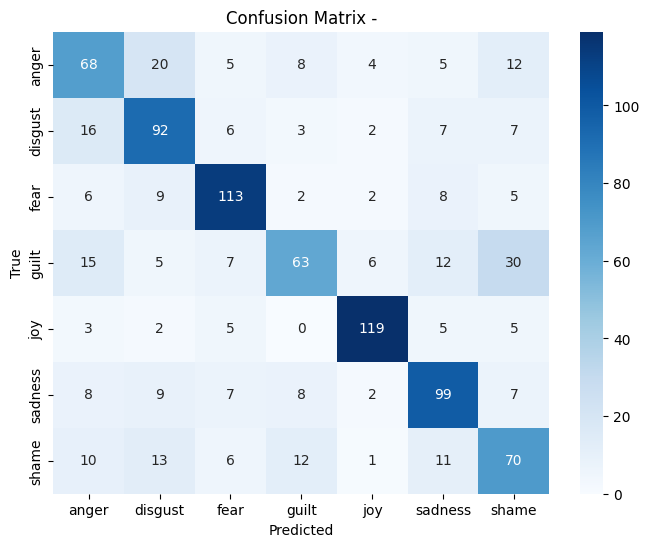

In [29]:
# Confusion Matrix
cm = confusion_matrix(test_labels, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title(f"Confusion Matrix -")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()


In [30]:
# Store results
results = {
    "accuracy": report["accuracy"],
    "f1": report["macro avg"]["f1-score"],
    "weight_f1": report["weighted avg"]["f1-score"],
    "precision": report["macro avg"]["precision"],
    "recall": report["macro avg"]["recall"],
}


In [31]:
results

{'accuracy': 0.6638297872340425,
 'f1': 0.6573747647217886,
 'weight_f1': 0.6622521654677659,
 'precision': 0.6615472006955546,
 'recall': 0.6596145875085794}